# 📊 Лабораторна робота 1 — Exploratory Data Analysis (EDA)
## Twitter Sentiment Analysis: Hate Speech Detection

**Мета:** Провести первинний аналіз даних (EDA) для датасету Twitter Sentiment Analysis,
дослідити розподіл класів, характеристики тексту та підготувати дані до навчання моделі.

## 1. Імпорт бібліотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import warnings

warnings.filterwarnings('ignore')

# Styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 2. Завантаження даних

In [2]:
df = pd.read_csv('../data/raw/twitter.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Dataset shape: (31962, 3)
Columns: ['id', 'label', 'tweet']


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
5,6,0,[2/2] huge fan fare and big talking before the...
6,7,0,@user camping tomorrow @user @user @user @use...
7,8,0,the next school year is the year for exams.ð...
8,9,0,we won!!! love the land!!! #allin #cavs #champ...
9,10,0,@user @user welcome here ! i'm it's so #gr...


## 3. Огляд структури даних

In [3]:
print('=== Info ===')
df.info()
print()
print('=== Describe ===')
df.describe()

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB

=== Describe ===


,id,label
count,31962.000000,31962.000000
mean,15981.500000,0.070146
std,9226.778988,0.255397
min,1.000000,0.000000
25%,7991.250000,0.000000
50%,15981.500000,0.000000
75%,23971.750000,0.000000
max,31962.000000,1.000000


In [4]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values! ✅')
print()
print('=== Duplicates ===')
print(f'Duplicate rows: {df.duplicated().sum()}')

=== Missing Values ===
No missing values! ✅

=== Duplicates ===
Duplicate rows: 0


## 4. Розподіл цільової змінної (Target Distribution)

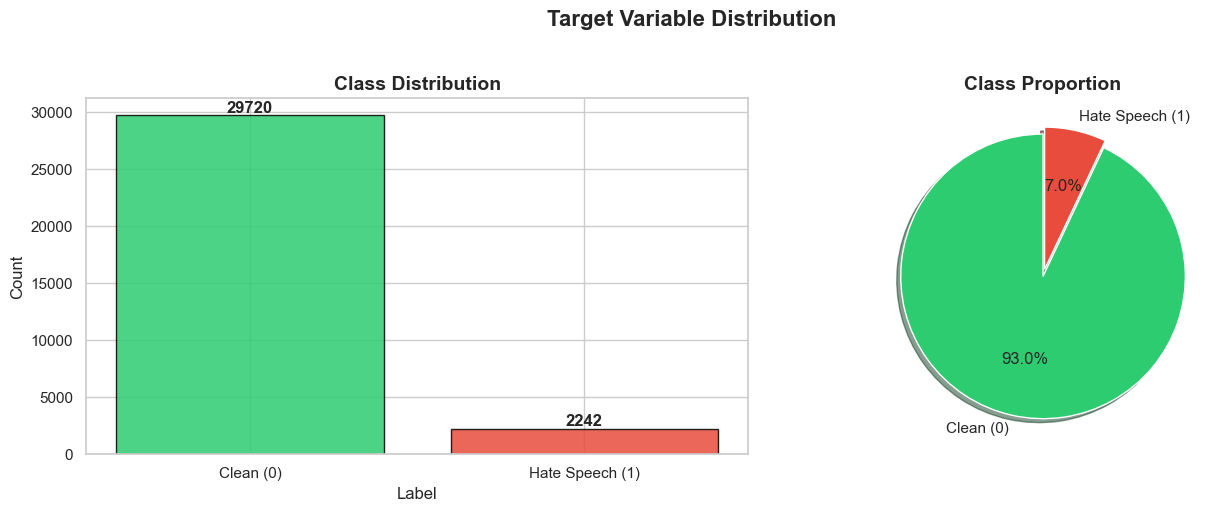


Class 0 (Clean):        29720 (93.0%)
Class 1 (Hate Speech):   2242 (7.0%)
Imbalance ratio:       1:13


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
label_counts = df['label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(label_counts.index.astype(str), label_counts.values, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Clean (0)', 'Hate Speech (1)'])
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=['Clean (0)', 'Hate Speech (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0, 0.05), shadow=True)
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nClass 0 (Clean):       {label_counts[0]:>6} ({label_counts[0]/len(df)*100:.1f}%)')
print(f'Class 1 (Hate Speech): {label_counts[1]:>6} ({label_counts[1]/len(df)*100:.1f}%)')
print(f'Imbalance ratio:       1:{label_counts[0]//label_counts[1]}')

## 5. Аналіз довжини твітів

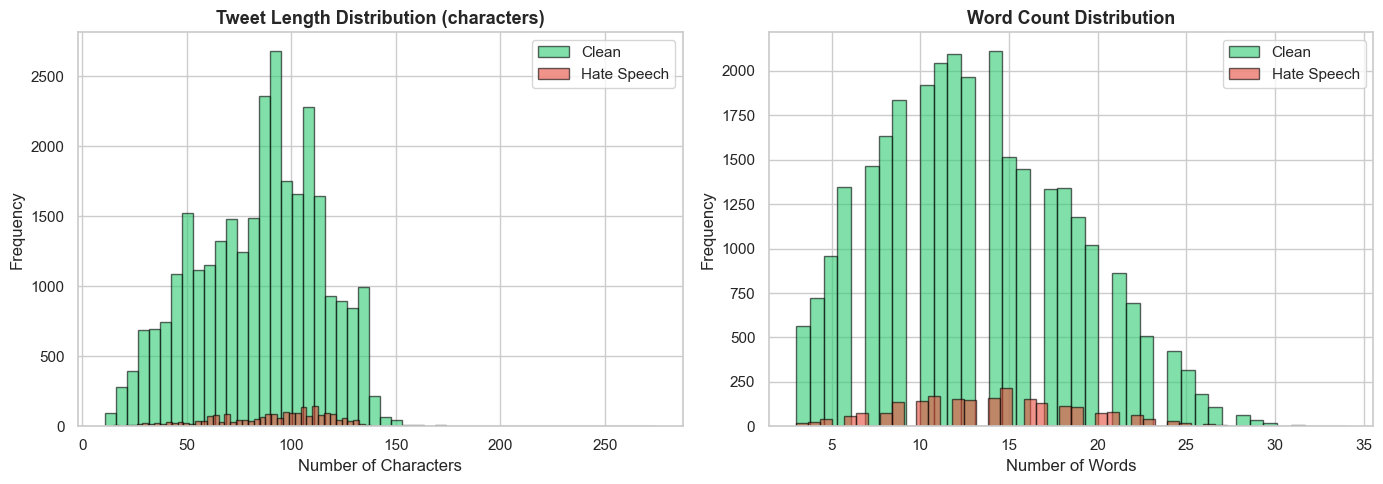


📊 Tweet Length Statistics:
      tweet_length                                             word_count  \
             count  mean   std   min   25%   50%    75%    max      count   
label                                                                       
0          29720.0  84.3  29.6  11.0  62.0  88.0  107.0  274.0    29720.0   
1           2242.0  90.2  27.4  12.0  69.0  96.0  111.0  152.0     2242.0   

                                               
       mean  std  min   25%   50%   75%   max  
label                                          
0      13.1  5.5  3.0   9.0  13.0  17.0  34.0  
1      14.1  5.0  3.0  10.0  14.0  17.0  30.0  


In [6]:
df['tweet_length'] = df['tweet'].apply(lambda x: len(str(x)))
df['word_count'] = df['tweet'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tweet length distribution
for label, color, name in [(0, '#2ecc71', 'Clean'), (1, '#e74c3c', 'Hate Speech')]:
    subset = df[df['label'] == label]
    axes[0].hist(subset['tweet_length'], bins=50, alpha=0.6, color=color, label=name, edgecolor='black')
axes[0].set_title('Tweet Length Distribution (characters)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Word count distribution
for label, color, name in [(0, '#2ecc71', 'Clean'), (1, '#e74c3c', 'Hate Speech')]:
    subset = df[df['label'] == label]
    axes[1].hist(subset['word_count'], bins=40, alpha=0.6, color=color, label=name, edgecolor='black')
axes[1].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

# Stats
print('\n📊 Tweet Length Statistics:')
print(df.groupby('label')[['tweet_length', 'word_count']].describe().round(1))

## 6. Передобробка тексту для аналізу

In [7]:
def clean_tweet(text):
    """Clean tweet text for analysis."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # URLs
    text = re.sub(r'@\w+', '', text)  # mentions
    text = re.sub(r'#(\w+)', r'\1', text)  # hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # special chars
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_tweet'] = df['tweet'].apply(clean_tweet)

print('✅ Text cleaned!')
print('\nOriginal vs Cleaned example:')
for i in range(3):
    print(f'  Original: {df["tweet"].iloc[i][:80]}...')
    print(f'  Cleaned:  {df["clean_tweet"].iloc[i][:80]}...')
    print()

✅ Text cleaned!

Original vs Cleaned example:
  Original:  @user when a father is dysfunctional and is so selfish he drags his kids into h...
  Cleaned:  when a father is dysfunctional and is so selfish he drags his kids into his dysf...

  Original: @user @user thanks for #lyft credit i can't use cause they don't offer wheelchai...
  Cleaned:  thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdx d...

  Original:   bihday your majesty...
  Cleaned:  bihday your majesty...



## 7. Найпоширеніші слова (Top Words)

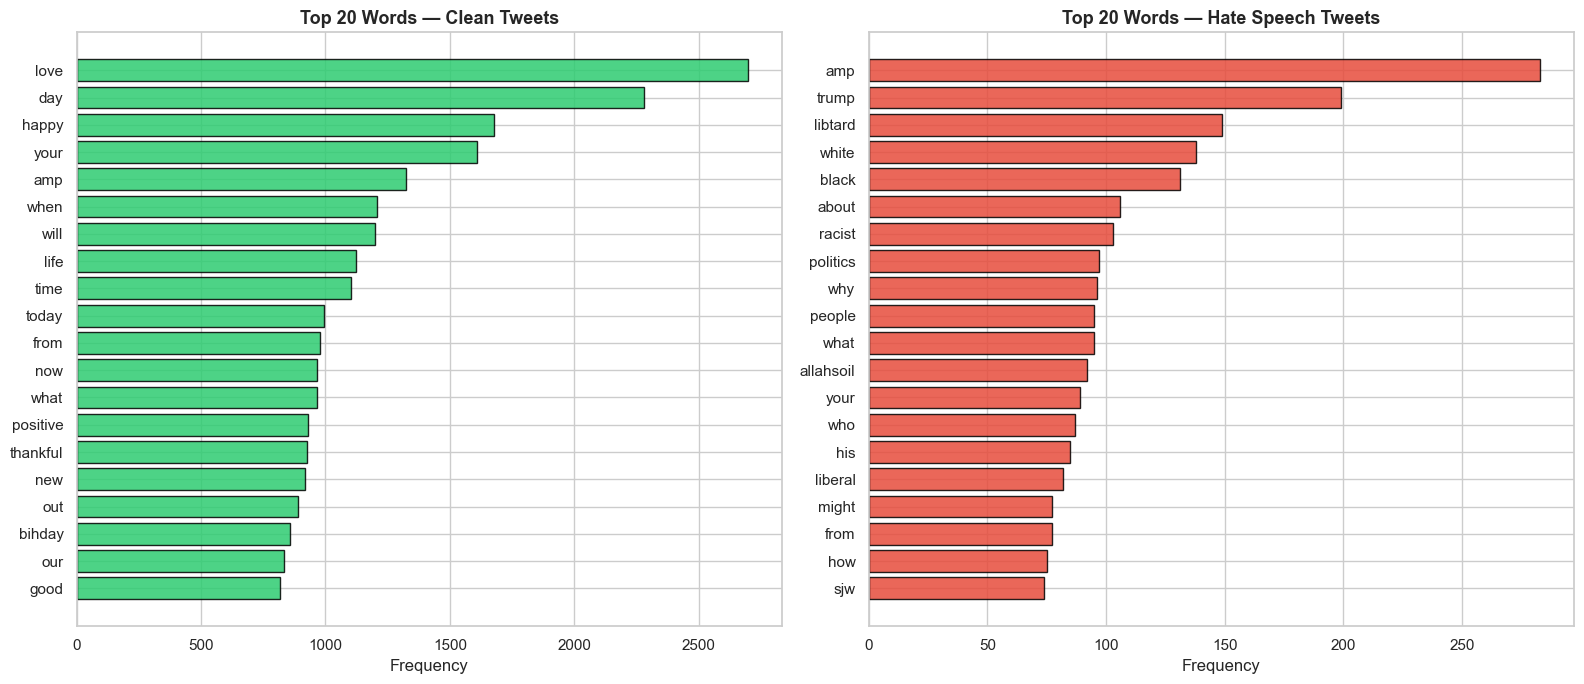

In [8]:
from collections import Counter

def get_top_words(texts, n=20):
    """Get top N most frequent words."""
    all_words = ' '.join(texts).split()
    # Remove common stopwords
    stopwords = {'the', 'a', 'an', 'is', 'it', 'to', 'in', 'of', 'and', 'for',
                 'on', 'that', 'this', 'with', 'i', 'you', 'my', 'me', 'not',
                 'are', 'was', 'but', 'at', 'be', 'have', 'has', 'he', 'she',
                 'they', 'we', 'so', 'if', 'do', 'just', 'all', 'or', 'rt',
                 'im', 'its', 'ur', 'dont', 'no', 'get', 'like', 'can'}
    words = [w for w in all_words if w not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, (label, title, color) in enumerate([(0, 'Clean Tweets', '#2ecc71'), (1, 'Hate Speech Tweets', '#e74c3c')]):
    top_words = get_top_words(df[df['label'] == label]['clean_tweet'])
    words, counts = zip(*top_words)
    axes[idx].barh(range(len(words)), counts, color=color, edgecolor='black', alpha=0.85)
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words)
    axes[idx].set_title(f'Top 20 Words — {title}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Frequency')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Word Clouds

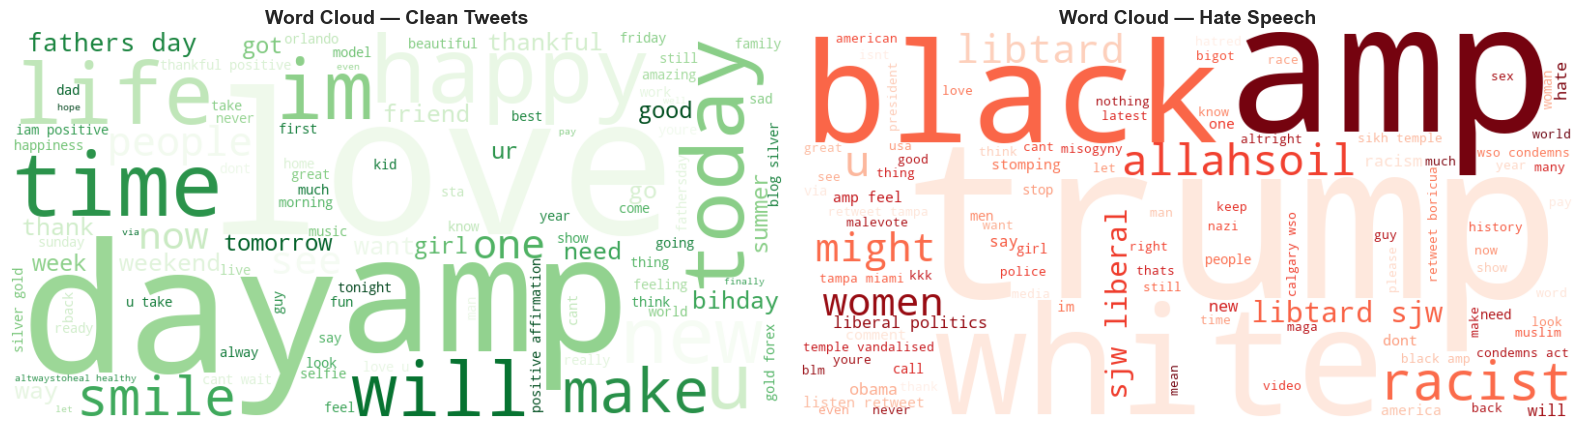

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, (label, title, colormap) in enumerate([(0, 'Clean Tweets', 'Greens'), (1, 'Hate Speech', 'Reds')]):
    text = ' '.join(df[df['label'] == label]['clean_tweet'])
    wc = WordCloud(width=800, height=400, max_words=100, background_color='white',
                   colormap=colormap, contour_width=1, contour_color='black').generate(text)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud — {title}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 9. Приклади твітів з кожного класу

In [10]:
print('=' * 60)
print('🟢 CLEAN TWEETS (label = 0) — Random samples')
print('=' * 60)
for tweet in df[df['label'] == 0]['tweet'].sample(5, random_state=42).values:
    print(f'  • {tweet}')
print()

print('=' * 60)
print('🔴 HATE SPEECH TWEETS (label = 1) — Random samples')
print('=' * 60)
for tweet in df[df['label'] == 1]['tweet'].sample(5, random_state=42).values:
    print(f'  • {tweet}')

🟢 CLEAN TWEETS (label = 0) — Random samples
  • #body to body massage with a   ending oil #massage ,body happyending massage center abu dhabi ,0506823156 
  •  @user @ my call back!  #casting #castingcall #model #cute #toddler #toddlerlife #photooftheday #nofilter #family   httâ¦
  • help creates the #environment of #togetherness &amp; #mutualrespect; prerequisites of a #sustainable,   and #healthy society.#fridayfeeling
  • summer with friendâ¨ð¥ #summer  #friend #life #vlog #weeknd   #crazy  i'll miss youð¼ð 
  • follow me on snapchat at awesomecutenes7 #snapchat #selfie #sad   #love #bff #yaaaaasssâ¦ 

🔴 HATE SPEECH TWEETS (label = 1) — Random samples
  • the latest the equality echo!  thanks to @user @user @user #equality 
  • amateur spanking vids  against women in the workplace 
  • @user the latest the blicqerâ¢ daily!  thanks to @user @user @user  #marketing
  • i wasn't aware facebook was a legislature. 
  • @user #goodes  #bolt  it's not the job of those who are di

## 10. Кореляційний аналіз числових ознак

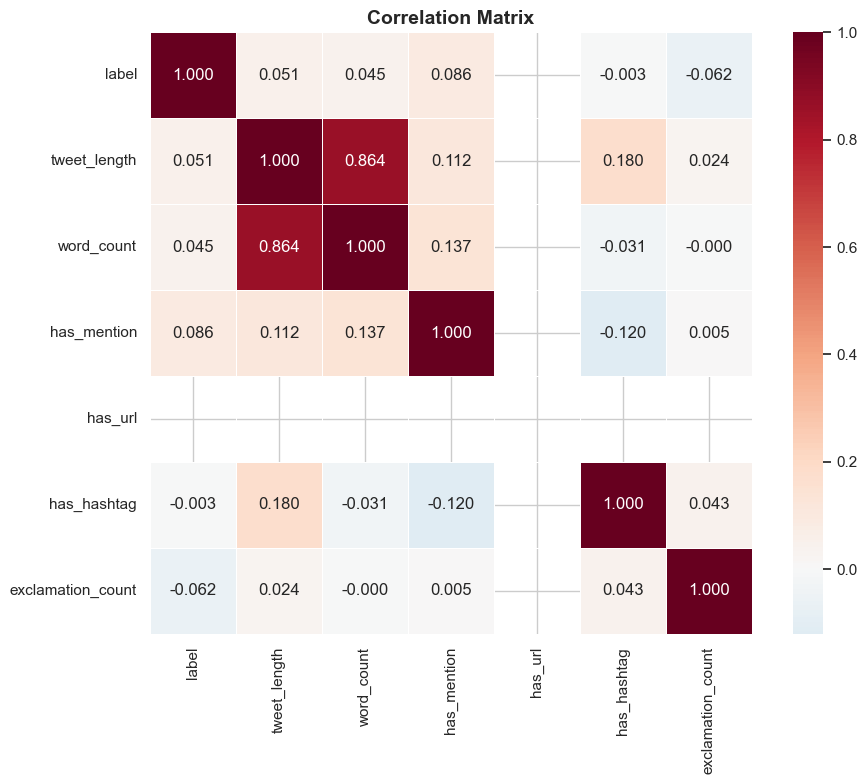

In [11]:
# Create additional numeric features for correlation
df['has_mention'] = df['tweet'].apply(lambda x: 1 if '@' in str(x) else 0)
df['has_url'] = df['tweet'].apply(lambda x: 1 if 'http' in str(x) else 0)
df['has_hashtag'] = df['tweet'].apply(lambda x: 1 if '#' in str(x) else 0)
df['exclamation_count'] = df['tweet'].apply(lambda x: str(x).count('!'))

numeric_cols = ['label', 'tweet_length', 'word_count', 'has_mention', 'has_url', 'has_hashtag', 'exclamation_count']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, fmt='.3f')
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Висновки EDA

### Основні спостереження:
1. **Дисбаланс класів:** Датасет значно незбалансований — чистих твітів набагато більше, ніж hate speech.
2. **Довжина тексту:** Розподіл довжини твітів подібний для обох класів.
3. **Ключові слова:** Hate speech твіти містять характерну лексику, яку модель може використати для класифікації.
4. **Дані потребують:** Очистку тексту, видалення URLs, mentions, спеціальних символів.

### Рекомендації для моделювання:
- Використати **F1-score** як основну метрику (через дисбаланс класів)
- Застосувати **TF-IDF** для перетворення тексту в числові ознаки
- Спробувати різні моделі: Logistic Regression, Random Forest, SVM